In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("Boston-house-price-data.csv")

Variables in order:

 CRIM  -  per capita crime rate by town

 ZN    -  proportion of residential land zoned for lots over 25,000 sq.ft.
 
 INDUS  -  proportion of non-retail business acres per town

 CHAS   -  Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)

 NOX   -   nitric oxides concentration (parts per 10 million)

 RM    -   average number of rooms per dwelling

 AGE   -   proportion of owner-occupied units built prior to 1940

 DIS   -   weighted distances to five Boston employment centres

 RAD   -   index of accessibility to radial highways

 TAX   -   full-value property-tax rate per $10,000

 PTRATIO - pupil-teacher ratio by town

 B    -  1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town

 LSTAT  -  % lower status of the population

 MEDV  -   Median value of owner-occupied homes in $1000's


Variáveis em ordem: 

CRIM - taxa de criminalidade per capita por cidade.

ZN - proporção de terrenos residenciais zoneados para lotes com mais de 25.000 pés quadrados. 

INDUS - proporção de acres de negócios não varejistas por cidade.

CHAS - Variável fictícia do Rio Charles (= 1 se o trato limita o rio; 0 caso contrário).

NOX - concentração de óxidos nítricos (partes por 10 milhões).

RM - número médio de quartos por habitação. 

IDADE - proporção de unidades ocupadas pelos proprietários construídas antes de 1940. 

DIS - distâncias ponderadas para cinco centros de emprego de Boston.

RAD - índice de acessibilidade a rodovias radiais.

IMPOSTO - taxa de imposto sobre propriedade de valor total por US$ 10.000.

PTRATIO - proporção aluno-professor por cidade B - 1000(Bk - 0,63)^2 onde Bk é a proporção de negros por cidade.

LSTAT - % menor status da população MEDV - Valor médio das casas ocupadas pelos proprietários em US$ 1.000.

In [2]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


## Tratamento de Dados

In [3]:
print(df.isnull().sum())

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CRIM,506.0,3.613524,8.601545,0.00632,0.082045,0.25651,3.677083,88.9762
ZN,506.0,11.363636,23.322453,0.00000,0.000000,0.00000,12.500000,100.0000
INDUS,506.0,11.136779,6.860353,0.46000,5.190000,9.69000,18.100000,27.7400
CHAS,506.0,0.069170,0.253994,0.00000,0.000000,0.00000,0.000000,1.0000
NOX,506.0,0.554695,0.115878,0.38500,0.449000,0.53800,0.624000,0.8710
RM,506.0,6.284634,0.702617,3.56100,5.885500,6.20850,6.623500,8.7800
AGE,506.0,68.574901,28.148861,2.90000,45.025000,77.50000,94.075000,100.0000
DIS,506.0,3.795043,2.105710,1.12960,2.100175,3.20745,5.188425,12.1265
RAD,506.0,9.549407,8.707259,1.00000,4.000000,5.00000,24.000000,24.0000
TAX,506.0,408.237154,168.537116,187.00000,279.000000,330.00000,666.000000,711.0000


In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

outlier_summary = []

for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    n_outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    
    if n_outliers > 0:
        outlier_summary.append({
            "coluna": col,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "limite_inferior": lower_bound,
            "limite_superior": upper_bound,
            "n_outliers": int(n_outliers)
        })
if outlier_summary:
    print(pd.DataFrame(outlier_summary))
else:
    print("Nenhuma coluna com outliers detectados pela técnica do IQR.")

    coluna          q1          q3        iqr  limite_inferior  \
0     CRIM    0.082045    3.677083   3.595038        -5.310511   
1       ZN    0.000000   12.500000  12.500000       -18.750000   
2     CHAS    0.000000    0.000000   0.000000         0.000000   
3       RM    5.885500    6.623500   0.738000         4.778500   
4      DIS    2.100175    5.188425   3.088250        -2.532200   
5  PTRATIO   17.400000   20.200000   2.800000        13.200000   
6        B  375.377500  396.225000  20.847500       344.106250   
7    LSTAT    6.950000   16.955000  10.005000        -8.057500   
8     MEDV   17.025000   25.000000   7.975000         5.062500   

   limite_superior  n_outliers  
0         9.069639          66  
1        31.250000          68  
2         0.000000          35  
3         7.730500          30  
4         9.820800           5  
5        24.400000          15  
6       427.496250          77  
7        31.962500           7  
8        36.962500          40  


In [7]:
df_sem_outliers = df.copy()

numeric_cols = df.select_dtypes(include=[np.number]).columns

mask = pd.Series(True, index=df.index)

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    mask &= (
        (df[col] >= lower_bound) &
        (df[col] <= upper_bound)
    )

df_sem_outliers = df[mask].copy()

## Gráficos

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

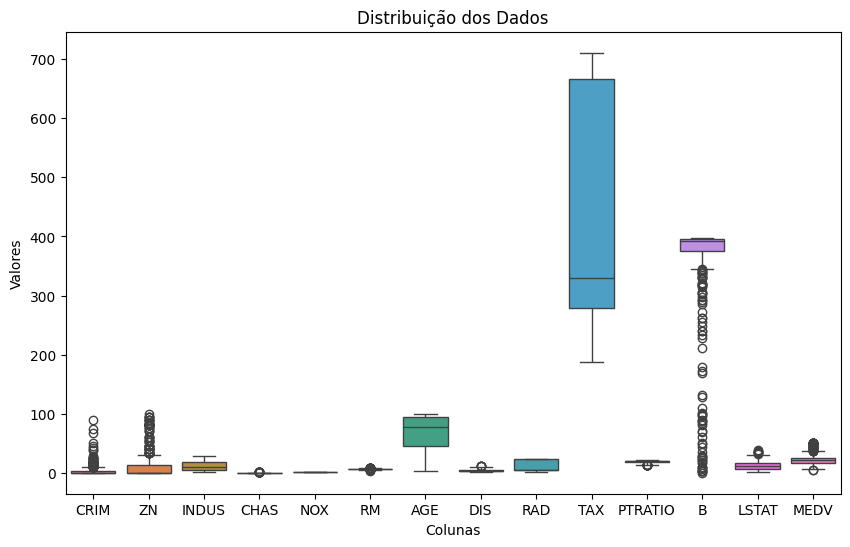

In [9]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df)
plt.title("Distribuição dos Dados")
plt.xlabel("Colunas")
plt.ylabel("Valores")
plt.show()

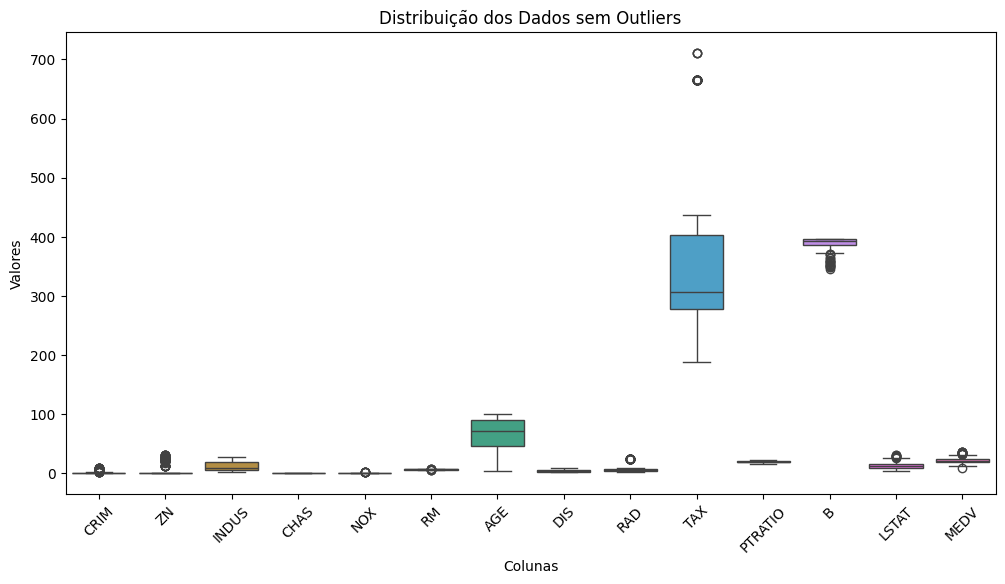

In [10]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_sem_outliers[numeric_cols])
plt.title("Distribuição dos Dados sem Outliers")
plt.xlabel("Colunas")
plt.ylabel("Valores")
plt.xticks(rotation=45)
plt.show()

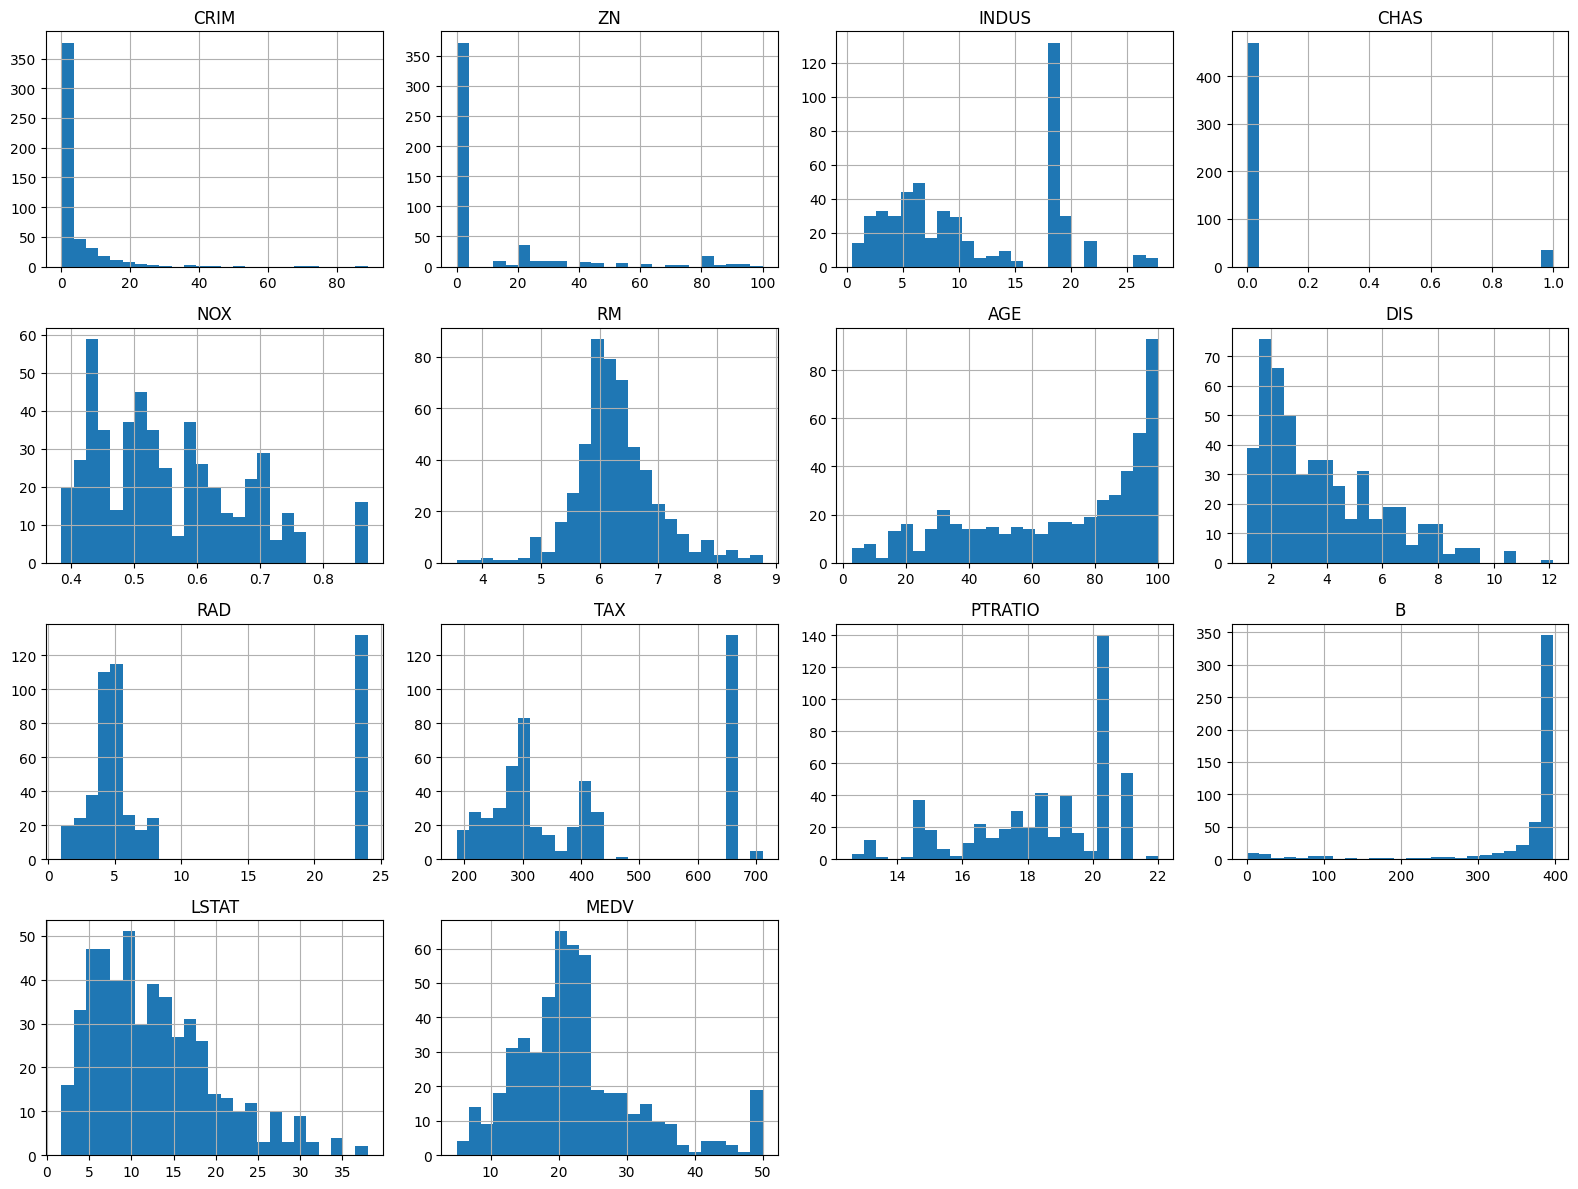

In [11]:
df.hist(figsize=(16, 12), bins=25)
plt.tight_layout()
plt.show()

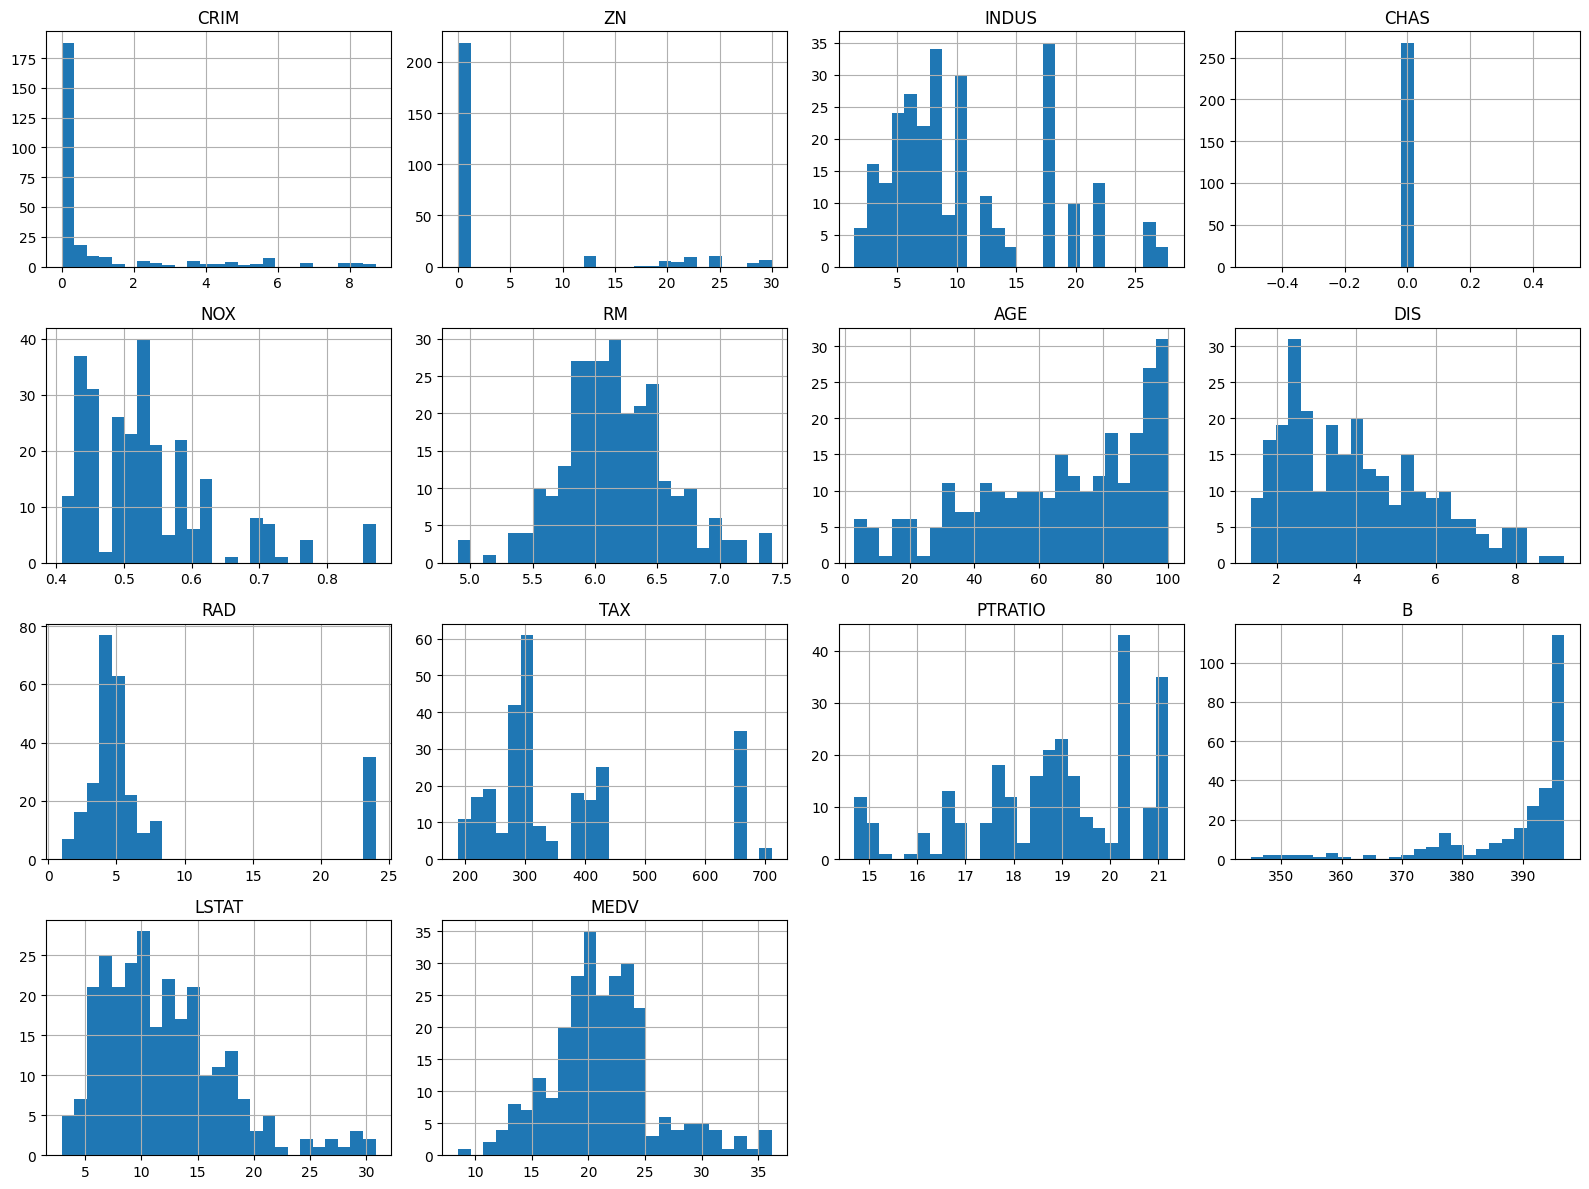

In [12]:
df_sem_outliers.hist(figsize=(16, 12), bins=25)
plt.tight_layout()
plt.show()

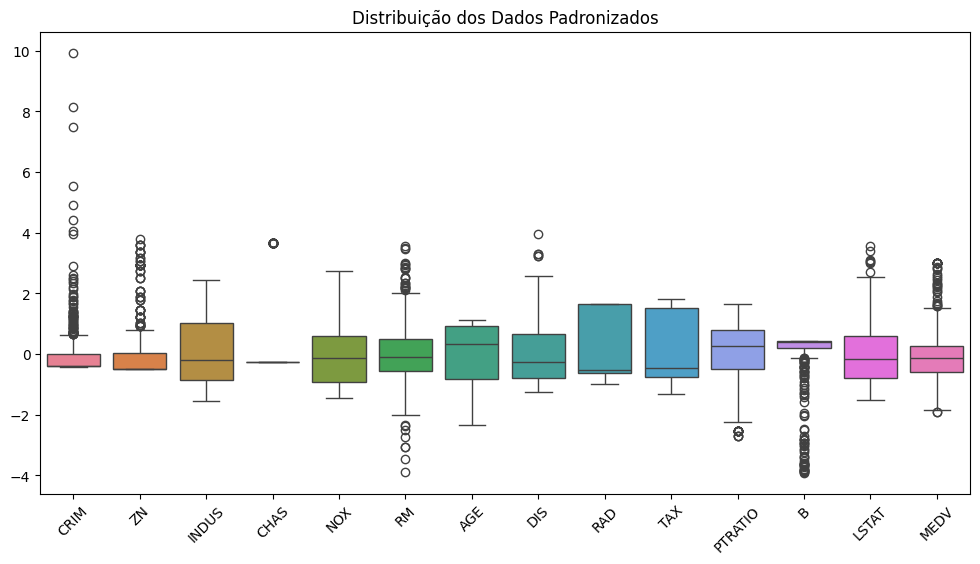

In [13]:
from sklearn.preprocessing import StandardScaler

df_padronizado = pd.DataFrame(
    StandardScaler().fit_transform(df[numeric_cols]),
    columns=numeric_cols
)

plt.figure(figsize=(12,6))
sns.boxplot(data=df_padronizado)
plt.xticks(rotation=45)
plt.title("Distribuição dos Dados Padronizados")
plt.show()

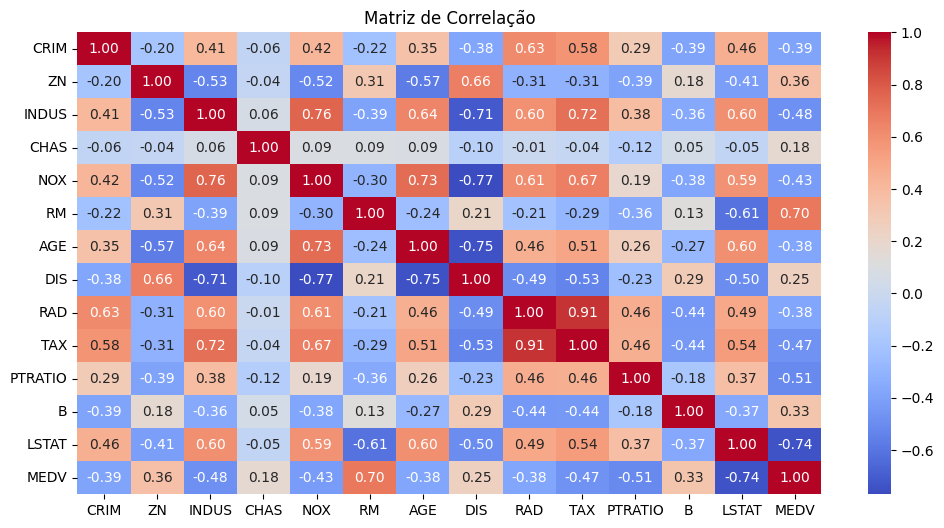

In [14]:
plt.figure(figsize=(12,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlação")
plt.show()

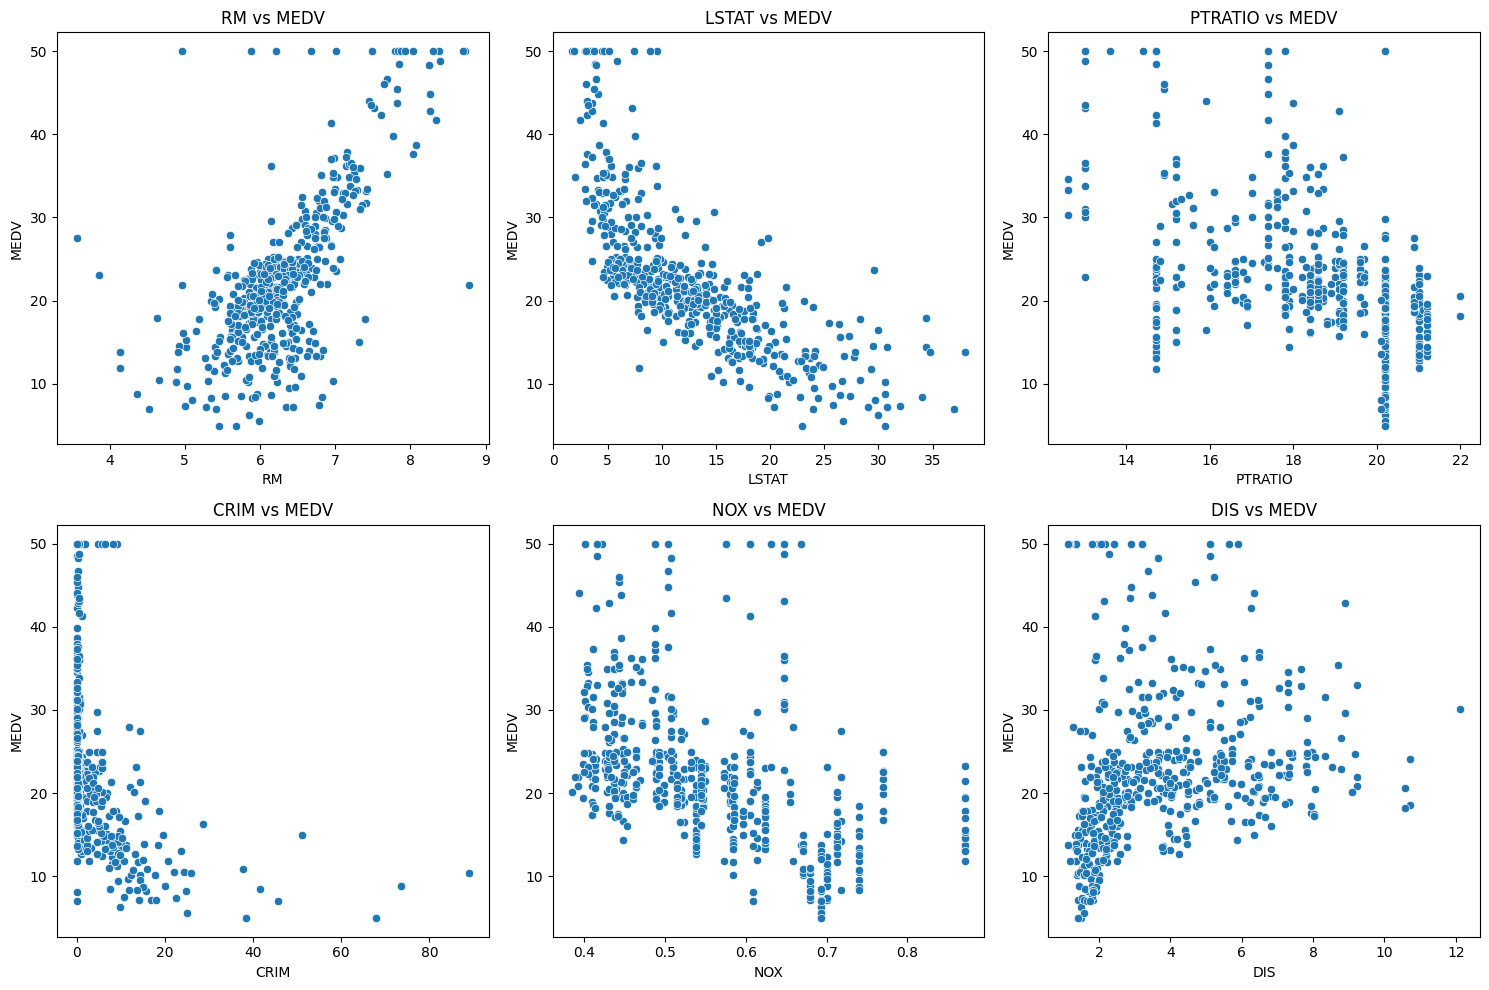

In [15]:
principais = ["RM", "LSTAT", "PTRATIO", "CRIM", "NOX", "DIS"]

fig, axes = plt.subplots(2, 3, figsize=(15,10))

for ax, coluna in zip(axes.flat, principais):
    sns.scatterplot(data=df, x=coluna, y="MEDV", ax=ax)
    ax.set_title(f"{coluna} vs MEDV")

plt.tight_layout()
plt.show()

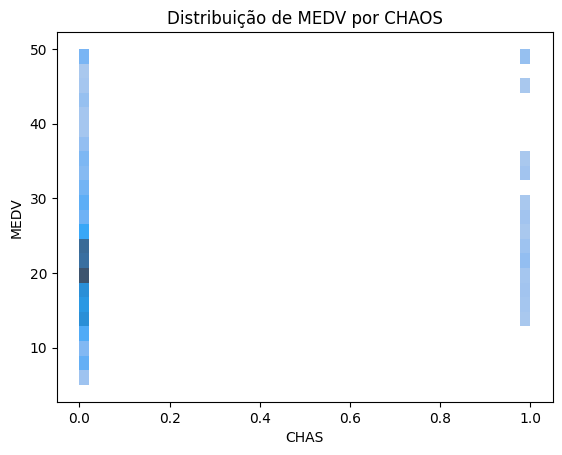

In [16]:
sns.histplot(data=df, x="CHAS", y="MEDV")
plt.title("Distribuição de MEDV por CHAOS")
plt.show()

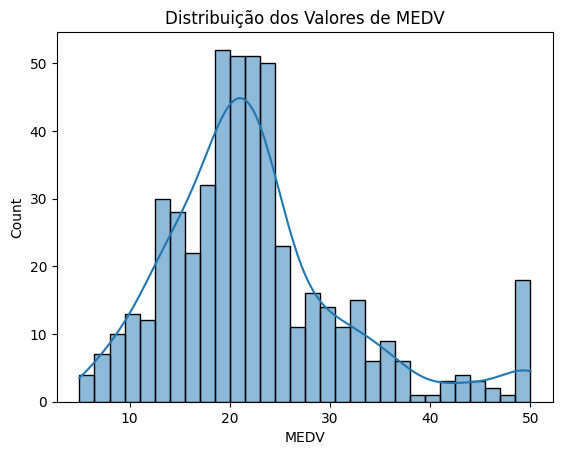

In [17]:
sns.histplot(data=df, x="MEDV", bins=30, kde=True)
plt.title("Distribuição dos Valores de MEDV")
plt.show()

Text(0.5, 1.0, 'Boxplot das Colunas Numéricas')

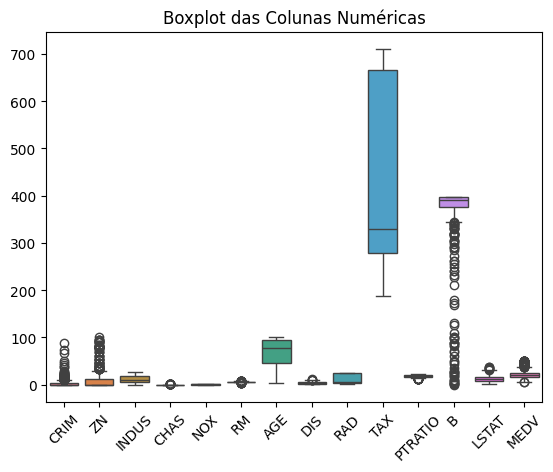

In [18]:
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45)
plt.title("Boxplot das Colunas Numéricas")

In [19]:
# Correlação de Medv com as outras colunas
correlacoes = (
    df.corr(numeric_only=True)["MEDV"]
    .drop("MEDV")
    .sort_values(key=abs, ascending=False)
)

correlacoes_percentual = (correlacoes * 100).round(2)

print(correlacoes_percentual)

LSTAT     -73.77
RM         69.54
PTRATIO   -50.78
INDUS     -48.37
TAX       -46.85
NOX       -42.73
CRIM      -38.83
RAD       -38.16
AGE       -37.70
ZN         36.04
B          33.35
DIS        24.99
CHAS       17.53
Name: MEDV, dtype: float64


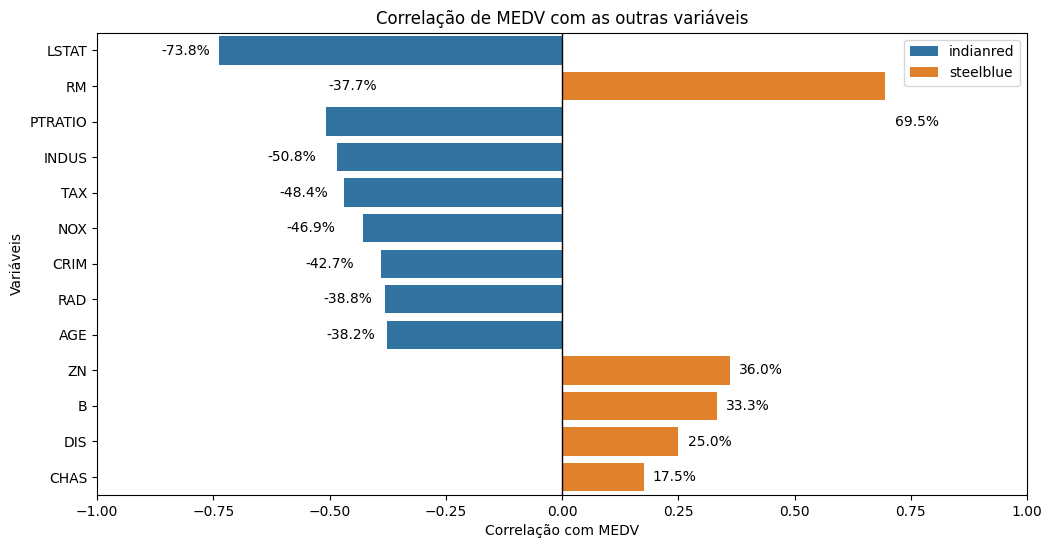

In [20]:
plt.figure(figsize=(12,6))

# Gráfico de barras para visualizar a correlação de MEDV com as outras variáveis
ax = sns.barplot(
    x=correlacoes.values,
    y=correlacoes.index,
    hue = ["steelblue" if valor >= 0 else "indianred" for valor in correlacoes.values]
)

# Adicionando uma linha vertical no ponto 0 para indicar a ausência de correlação
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Correlação com MEDV")
plt.ylabel("Variáveis")
plt.title("Correlação de MEDV com as outras variáveis")

# Adicionando os valores de correlação no gráfico
for barra, valor in zip(ax.patches, correlacoes.values):
    ax.text(
        valor + (0.02 if valor >= 0 else -0.02),
        barra.get_y() + barra.get_height() / 2,
        f"{valor * 100:.1f}%",
        va="center",
        ha="left" if valor >= 0 else "right"
    )

# Ajustando os limites do eixo x para melhor visualização
plt.xlim(-1, 1)
plt.show()

In [21]:
fortes = correlacoes[abs(correlacoes) >= 0.5]
print("Colunas com correlação forte com MEDV:")
print((fortes * 100).round(2))

Colunas com correlação forte com MEDV:
LSTAT     -73.77
RM         69.54
PTRATIO   -50.78
Name: MEDV, dtype: float64


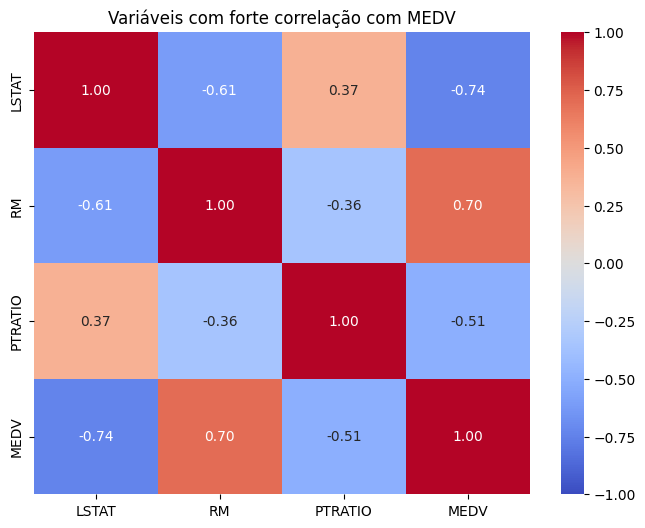

In [22]:
colunas_selecionadas = fortes.index.tolist() + ["MEDV"]

plt.figure(figsize=(8, 6))
sns.heatmap(
    df[colunas_selecionadas].corr(),
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f"
)

plt.title("Variáveis com forte correlação com MEDV")
plt.show()

## Aprendizado de Máquina

In [23]:
from sklearn.model_selection import train_test_split

X = df.drop(columns="MEDV")
y = df["MEDV"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

modelos = {
    "Regressão Linear": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

resultados = []

for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)

    previsoes = modelo.predict(X_test)

    mae = mean_absolute_error(y_test, previsoes)
    rmse = np.sqrt(mean_squared_error(y_test, previsoes))
    r2 = r2_score(y_test, previsoes)

    resultados.append({
        "modelo": nome,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

resultados_df = pd.DataFrame(resultados)
resultados_df

# MAE: Erro Médio Absoluto, Quanto menor o valor, melhor o modelo.
# RMSE: Raiz do Erro Quadrático Médio, Quanto menor o valor, melhor o modelo.
# R2: Indicador de quão bem o modelo explica a variabilidade dos dados, no caso MEDV. Quanto mais próximo de 1, melhor o modelo.

,modelo,MAE,RMSE,R2
0,Regressão Linear,3.189092,4.928602,0.668759
1,Random Forest,2.039539,2.810963,0.892253
2,Gradient Boosting,1.912243,2.491759,0.915334


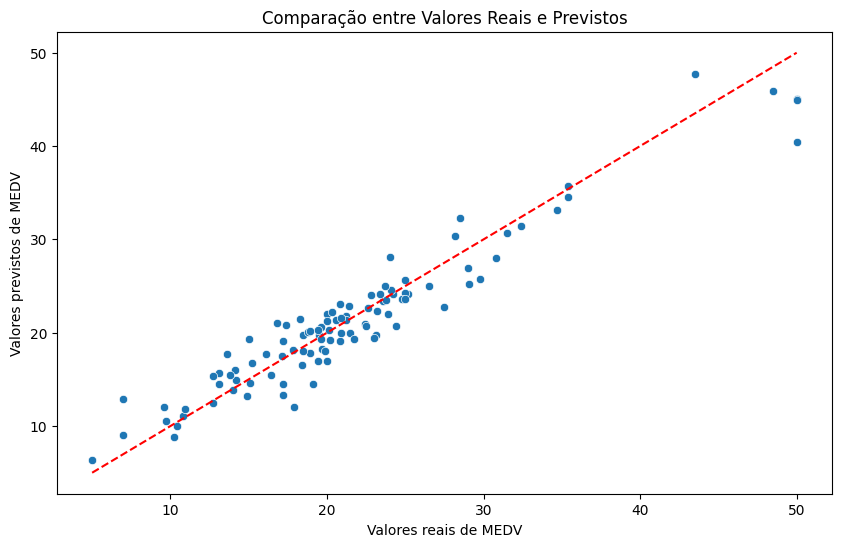

In [26]:
modelo_final = modelos["Gradient Boosting"]
modelo_final.fit(X_train, y_train)

previsoes = modelo_final.predict(X_test)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=previsoes)

limite_minimo = min(y_test.min(), previsoes.min())
limite_maximo = max(y_test.max(), previsoes.max())

plt.plot(
    [limite_minimo, limite_maximo],
    [limite_minimo, limite_maximo],
    color="red",
    linestyle="--"
)

plt.xlabel("Valores reais de MEDV")
plt.ylabel("Valores previstos de MEDV")
plt.title("Comparação entre Valores Reais e Previstos")
plt.show()

# Quanto mais próximo da linha vermelha, melhor o modelo está prevendo os valores de MEDV.

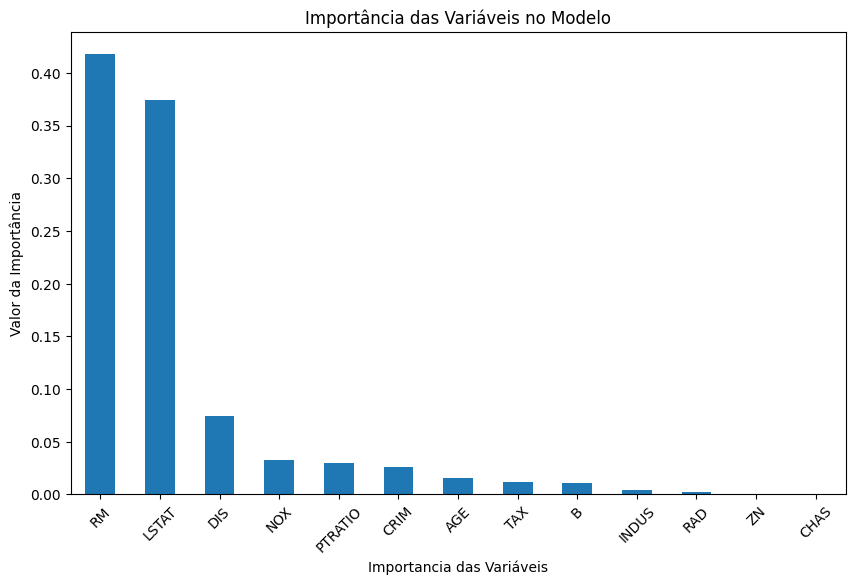

In [27]:
importancias = pd.Series(
    modelo_final.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importancias.plot(kind="bar")

plt.xlabel("Importancia das Variáveis")
plt.ylabel("Valor da Importância")
plt.title("Importância das Variáveis no Modelo")
plt.xticks(rotation=45)
plt.show()

# O Gráfico ajuda a identificar quais variáveis têm maior influência na previsão do valor das casas (MEDV). 
# Variáveis com maior importância contribuem mais para o modelo, enquanto variáveis com menor importância podem ser menos relevantes para a previsão.

In [28]:
from sklearn.model_selection import cross_validate, KFold

cross_val = KFold(n_splits=5, shuffle=True, random_state=42)

resultados_cross_val =  []

for nome, modelo in modelos.items():
    resultado = cross_validate(
        modelo,
        X,
        y,
        cv=cross_val,
        scoring={
            "MAE": "neg_mean_absolute_error",
            "RMSE": "neg_root_mean_squared_error",
            "R2": "r2"
        }
    )

    resultados_cross_val.append({
        "modelo": nome,
        "MAE médio": -resultado["test_MAE"].mean(),
        "RMSE_médio": -resultado["test_RMSE"].mean(),
        "R2_médio": resultado["test_R2"].mean()
    })

pd.DataFrame(resultados_cross_val)

,modelo,MAE médio,RMSE_médio,R2_médio
0,Regressão Linear,3.388460,4.842789,0.715222
1,Random Forest,2.194479,3.243030,0.871432
2,Gradient Boosting,2.092412,2.926857,0.894967


In [29]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

modelos["Regressão Linear"] = make_pipeline(
    StandardScaler(),
    LinearRegression()
)

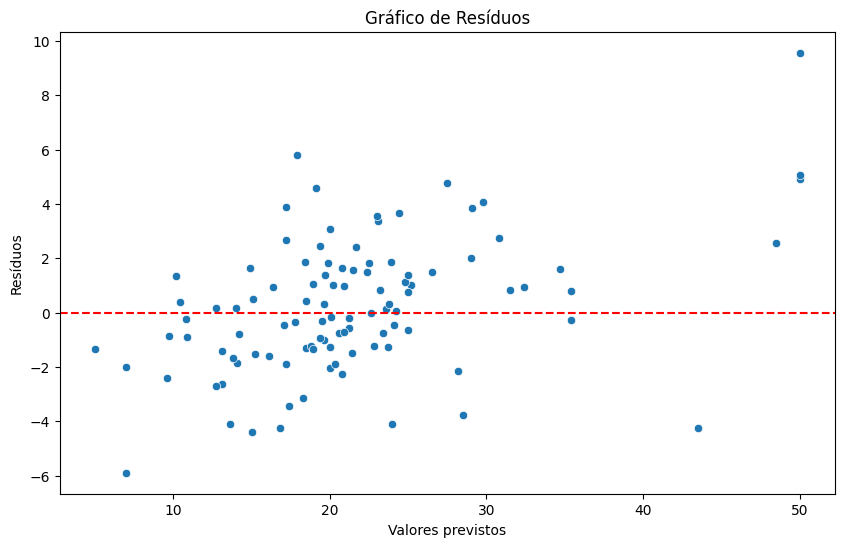

In [30]:
residuos = y_test - previsoes

plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=residuos)
plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Valores previstos")
plt.ylabel("Resíduos")
plt.title("Gráfico de Resíduos")
plt.show()

In [31]:
from sklearn.model_selection import GridSearchCV

parametros = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10,20],
    "min_samples_split": [2, 5, 10]
}

busca = GridSearchCV(
    RandomForestRegressor(random_state=42),
    parametros,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

busca.fit(X_train, y_train)

print("Melhores parâmetros:", busca.best_params_)
print("Melhor RMSE:", -busca.best_score_)

Melhores parâmetros: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Melhor RMSE: 3.819277104790916


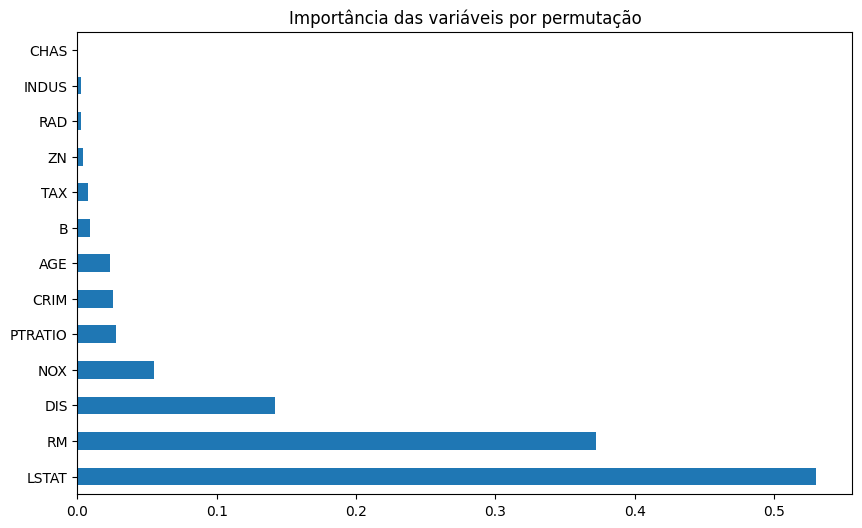

In [32]:
from sklearn.inspection import permutation_importance

importancia_de_resultados = permutation_importance(
    modelo_final,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

importancias = pd.Series(
    importancia_de_resultados.importances_mean,
    index=X.columns
).sort_values(ascending=False)

importancias.plot(kind="barh", figsize=(10, 6))
plt.title("Importância das variáveis por permutação")
plt.show()

In [33]:
#import joblib

#joblib.dump(modelo_final, "modelo_boston.pkl")

In [34]:
#modelo_carregado = joblib.load("modelo_boston.pkl")

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [36]:
# Remove a coluna "MEDV"
X_cluster = df.drop(columns="MEDV")

# Padroniza os dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Avaliação de diferentes quantidades de grupos
resultados_kmeans = []

for k in range(2, 11):
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    grupos = modelo.fit_predict(X_scaled)
    
    resultados_kmeans.append({
        "k": k,
        "inércia": modelo.inertia_,
        "silhouette": silhouette_score(X_scaled, grupos)
    })

resultados_kmeans = pd.DataFrame(resultados_kmeans)
resultados_kmeans


,k,inércia,silhouette
0,2,4196.159291,0.360118
1,3,3514.390414,0.257489
2,4,3122.439998,0.265817
3,5,2729.988853,0.287816
4,6,2441.810185,0.262484
5,7,2201.385713,0.291773
6,8,2078.368385,0.293329
7,9,1850.083563,0.289356
8,10,1755.597721,0.285033


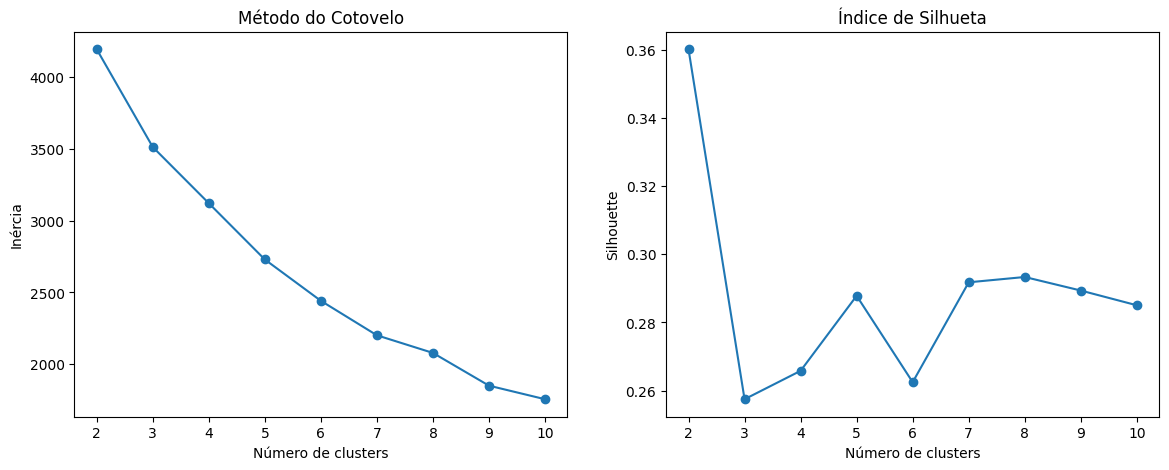

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    resultados_kmeans["k"],
    resultados_kmeans["inércia"],
    marker="o"
)
axes[0].set_title("Método do Cotovelo")
axes[0].set_xlabel("Número de clusters")
axes[0].set_ylabel("Inércia")

axes[1].plot(
    resultados_kmeans["k"],
    resultados_kmeans["silhouette"],
    marker="o"
)
axes[1].set_title("Índice de Silhueta")
axes[1].set_xlabel("Número de clusters")
axes[1].set_ylabel("Silhouette")

plt.show()

In [38]:
k_escolhido = 4

kmeans = KMeans(
    n_clusters=k_escolhido,
    random_state=42,
    n_init=10
)

df_clusterizado = df.copy()
df_clusterizado["cluster"] = kmeans.fit_predict(X_scaled)

df_clusterizado.groupby("cluster").mean(numeric_only=True)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
cluster,,,,,,,,,,,,,,
0,0.281869,4.351111,7.245600,0.044444,0.504760,6.340502,63.805333,4.104101,4.586667,299.146667,18.328889,386.099822,10.675644,24.042222
1,12.759291,0.000000,18.100000,0.060606,0.672417,6.022152,89.805303,2.061254,24.000000,666.000000,20.200000,288.089167,18.600606,16.403788
2,0.066155,54.839080,3.665517,0.057471,0.423445,6.750471,30.463218,6.895371,4.195402,304.022989,16.879310,388.945862,6.097126,29.354023
3,1.210333,0.000000,20.916935,0.193548,0.669452,5.987048,94.162903,2.014292,4.306452,401.580645,17.412903,350.621613,16.366129,20.532258
